# Lesson 02a: `o3.Irreps` are the Type System of Equivariant Networks

**What you will learn**

- The `o3.Irreps` notation: what does the expression `"16x0e + 8x1o"` mean and what do multiplicity and parity entail for describing a feature tensor.
- How e3nn lays out features in memory.
- Features transformation, the usages of `Irreps.D_from_matrix` and our course-wide equivariance test harness `course_utils.equivariance.assert_equivariant`.
- Which simple operations are equivariant (per-irrep scaling) and which are not (elementwise nonlinearities on $l>0$ components).
- **Pseudo-scalars (`0o`) and pseudo-vectors (`1e`)** with physical examples: chirality via the triple product, angular momentum via the cross product.

**Prerequisites:**

- [Lesson 01b](01b_group_representations.ipynb) or
- familiarity with irreps of $O(3)$ labeled by $(l, p)$, Wigner D-matrices, block-diagonal structure of reducible representations in the irreps basis.

In [1]:
import sys; sys.path.insert(0, "..")  # make course_utils importable

import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3

from course_utils.equivariance import assert_equivariant, equivariance_error

torch.set_default_dtype(torch.float64)  # equivariance checks at ~1e-15, not 1e-6
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__} | device: {device}")

torch 2.7.1+cu126 | device: cuda


## The notation: `"16x0e + 8x1o"`

Lesson 01b established that every finite-dimensional representation of $O(3)$ is a direct sum of irreps $(l, p)$. e3nn turns this fact into a **type annotation**: every feature tensor in an equivariant network is declared as

$$ \underbrace{16 \times (0, e)}_{16 \text{ scalars}} \;\oplus\; \underbrace{8 \times (1, o)}_{8 \text{ vectors}} \qquad\longleftrightarrow\qquad \texttt{"16x0e + 8x1o"} $$

Read `MULxLP` as: **multiplicity** `MUL` copies of the irrep with angular momentum degree `L` and parity `P` (`e` = even, `o` = odd). Each copy of irrep $(l,p)$ occupies $2l+1$ consecutive numbers, so the total dimension here is $16 \cdot 1 + 8 \cdot 3 = 40$.

The declaration tells e3nn *exactly* how the 40 numbers transform under any $g \in O(3)$. This is what a neural network layer needs to know to stay equivariant. It is a type system in the programming-language sense: operations between features are legal only when their irrep types are compatible, or e3nn will raise error otherwise.

In [2]:
irreps = o3.Irreps("16x0e + 8x1o")
print(f"irreps      = {irreps}")
print(f"dim         = {irreps.dim}          (16*1 + 8*3)")
print(f"num_irreps  = {irreps.num_irreps}   (16 + 8 copies in total)")
print(f"lmax        = {irreps.lmax}")

for mul_ir in irreps:                      # iterate over (multiplicity, irrep) pairs
    mul, ir = mul_ir.mul, mul_ir.ir
    print(f"  {mul:>2} copies of {ir}:  l={ir.l}, parity p={ir.p:+d}, "
          f"irrep dim {ir.dim}, block dim {mul_ir.dim}")

irreps      = 16x0e+8x1o
dim         = 40          (16*1 + 8*3)
num_irreps  = 24   (16 + 8 copies in total)
lmax        = 1
  16 copies of 0e:  l=0, parity p=+1, irrep dim 1, block dim 16
   8 copies of 1o:  l=1, parity p=-1, irrep dim 3, block dim 24


## Direct sums and algebra on `Irreps`

`Irreps` objects behave like the direct sums they denote: `+` concatenates, integer multiplication repeats, and `.sort()` / `.simplify()` bring an expression to a normal form (sorted by $l$, equal irreps merged). These are *bookkeeping* operations on the types and no feature data is involved yet.

In [3]:
a, b = o3.Irreps("0e + 1o"), o3.Irreps("2e")
print(f"a + b          = {a + b}")
print(f"3 * a          = {3 * a}")
print(f"normal form    = {(3 * a).sort().irreps.simplify()}")
print(f"'1o' in a      : {o3.Irrep('1o') in a}")
print(f"all irreps with l <= 2: {[str(ir) for ir in o3.Irrep.iterator(2)]}")

a + b          = 1x0e+1x1o+1x2e
3 * a          = 1x0e+1x1o+1x0e+1x1o+1x0e+1x1o
normal form    = 3x0e+3x1o
'1o' in a      : True
all irreps with l <= 2: ['0e', '0o', '1o', '1e', '2e', '2o']


## Memory layout and slicing

A tensor typed `irreps` has its last dimension of size `irreps.dim`, laid out **in the order written**: first all copies of the first entry, then the next, etc. Within a block of `MULxLP`, the `MUL` copies are contiguous. The resulting block reshapes to `(..., MUL, 2l+1)`. `irreps.slices()` returns one `slice` per entry, and `irreps.randn(*size)` samples i.i.d. normal features (`-1` marks the irreps axis).

In [4]:
# dim 2 + 6 + 5 = 13
feat_irreps = o3.Irreps("2x0e + 2x1o + 1x2e")

# a batch of 4 feature vectors
x = feat_irreps.randn(4, -1)
print(f"x.shape = {tuple(x.shape)}   (batch, irreps.dim = {feat_irreps.dim})")

# reshape each block to (batch, mul, 2l+1)
for mul_ir, sl in zip(feat_irreps, feat_irreps.slices()):
    block = x[:, sl].reshape(4, mul_ir.mul, mul_ir.ir.dim)
    print(f"  {str(mul_ir):>6}  <- x[:, {sl.start:>2}:{sl.stop:<2}]  "
          f"reshaped to (batch, mul, 2l+1) = {tuple(block.shape)}")

x.shape = (4, 13)   (batch, irreps.dim = 13)
    2x0e  <- x[:,  0:2 ]  reshaped to (batch, mul, 2l+1) = (4, 2, 1)
    2x1o  <- x[:,  2:8 ]  reshaped to (batch, mul, 2l+1) = (4, 2, 3)
    1x2e  <- x[:,  8:13]  reshaped to (batch, mul, 2l+1) = (4, 1, 5)


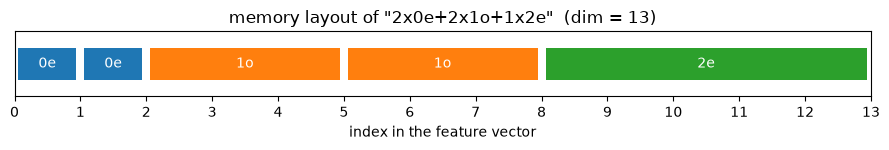

In [5]:
# The layout, drawn: one colored span per irrep copy, ticks at slice boundaries
fig, ax = plt.subplots(figsize=(9, 1.6))
# Color by l, fixed assignment
colors = {0: "C0", 1: "C1", 2: "C2"}

# Draw the layout of the feature vector
start = 0
for mul_ir in feat_irreps:
    # one span per copy
    for _ in range(mul_ir.mul):
        ax.barh(0, mul_ir.ir.dim - 0.12, left=start + 0.06, height=0.6,
                color=colors[mul_ir.ir.l], edgecolor="none")
        ax.text(start + mul_ir.ir.dim / 2, 0, str(mul_ir.ir),
                ha="center", va="center", color="white", fontsize=10)
        start += mul_ir.ir.dim
ax.set_xlim(0, feat_irreps.dim); ax.set_ylim(-0.6, 0.6)
ax.set_yticks([]); ax.set_xticks(range(feat_irreps.dim + 1))
ax.set_xlabel("index in the feature vector")
ax.set_title(f'memory layout of "{feat_irreps}"  (dim = {feat_irreps.dim})')
fig.tight_layout()

## How typed features transform and how to test their equivariance

Having presented the irreps types, we can now demonstrate that for an element of the group, $g \in O(3)$, (represented by a $3\times 3$ orthogonal matrix), the feature vector transforms with the block-diagonal matrix

$$ 
   x \;\longmapsto\; D(g)\,x, \\[5pt]
   D(g) = \bigoplus_{\text{copies } (l,p)} D^{(l,p)}(g), 
$$

which can be created by `irreps.D_from_matrix(g)` (Lesson 01b). From now on, every operation we build gets an immediate numerical test against the definition of equivariance $f(D_{\text{in}}(g)\,x) = D_{\text{out}}(g)\,f(x)$ for which we will adopt `course_utils.equivariance.assert_equivariant`. This function draws random symmetry operations from $g \in O(3)$ (rotations, half of them composed with the inversion) and reports the worst deviation. Another sanity check we can use is the identity map because it is equivariant (with equal input/output types).

In [6]:
# Create the transformation matrix for a random rotation
D = feat_irreps.D_from_matrix(o3.rand_matrix())
print(f"D(g): {tuple(D.shape)} block-diagonal matrix\n")

# The identity map, typed "13 numbers of 2x0e+2x1o+1x2e in, same out"
assert_equivariant(lambda x: x, irreps_in=feat_irreps, irreps_out=feat_irreps)

D(g): (13, 13) block-diagonal matrix

equivariant!  (max error 0.000e+00 over random O(3) elements)


0.0

An important question is: Which mappings remain equivariant under transformation?

By Schur's lemma (Lesson 01b: irreps never mix), a linear map is equivariant iff it only **mixes multiplicity channels of the same irrep**, acting identically on the $2l+1$ components of each copy. Scaling every irrep element by its own value is the simplest example. In contrast, any elementwise nonlinear mapping, acting on $l>0$ components, breaks the equivariance. Such a nonlinear operation, for example, treats the components of a vector as three independent scalars, which they are not.

In [7]:
# One number per copy (2+2+1 copies)
weights = torch.tensor([2.0, -1.0, 0.5, 3.0, 1.5])

def scale_per_irrep(x):
    '''Multiply each irrep copy by a fixed scalar -- an equivariant linear map.'''
    out, i = [], 0
    for mul_ir, sl in zip(feat_irreps, feat_irreps.slices()):
        # (batch, mul, 2l+1)
        block = x[:, sl].reshape(-1, mul_ir.mul, mul_ir.ir.dim)
        w = weights[i : i + mul_ir.mul]
        i += mul_ir.mul
        # same scalar on all 2l+1
        out.append((w[:, None] * block).flatten(1))
    return torch.cat(out, dim=-1)

assert_equivariant(scale_per_irrep, feat_irreps, feat_irreps)

err = equivariance_error(torch.relu, feat_irreps, feat_irreps)
print(f"elementwise ReLU:  max equivariance error = {err:.3f}  -> NOT equivariant")

equivariant!  (max error 1.776e-15 over random O(3) elements)
elementwise ReLU:  max equivariance error = 2.394  -> NOT equivariant


ReLU fails the equivariance test by a large margin. This is *the* central tension of equivariant network design as nonlinearities are what make neural networks expressive, but can destroy equivariance. In, Lesson 04 we resolves this issue.

## Pseudo-scalars and pseudo-vectors: `0o` and `1e`

Parity gives four "flavors" to the low-$l$ types. Among these four types, two (pseudo-scalar and pseudo-vector) may be less familiar to most people but they are physically essential:

| type | name | transforms under $R$ | under inversion $P$ | physical examples |
|---|---|---|---|---|
| `0e` | scalar | unchanged | $+$ | energy, mass, $\lVert\vec r\rVert$ |
| `0o` | **pseudo-scalar** | unchanged | $-$ | chirality measures, magnetic charge |
| `1o` | vector | $R\vec v$ | $-$ | position, velocity, force, dipole |
| `1e` | **pseudo-vector** | $R\vec v$ | $+$ | angular momentum $\vec r \times \vec p$, magnetic field, torque |

Both pseudo-scalars and pseudo-vectors arise from products of ordinary vectors:

- **cross product**: $\vec a \times \vec b$ with $\vec a, \vec b$ of type `1o` rotates like a vector but is *unchanged* under inversion ($(-\vec a) \times (-\vec b) = \vec a \times \vec b$) $\rightarrow$ type `1e`;
- **triple product**: $\vec a \cdot (\vec b \times \vec c) = \det[\vec a, \vec b, \vec c]$ is rotation-invariant but *flips sign* under inversion $\rightarrow$ type `0o`. A nonzero triple product can distinguish a structure from its mirror image. As such, it is a **chirality detector**, which no `0e`-only network can express (Lesson 06b makes this concrete on the Tetris dataset);

We verify both claims with our test harness which also includes improper elements!

In [8]:
# cross product: (1o, 1o) -> 1e; 
# Input typed "2x1o" = two stacked vectors
def cross(x):
    # x: (batch, 6) = [a | b]
    return torch.cross(x[:, :3], x[:, 3:], dim=-1)

def triple(x):
    # x: (batch, 9) = [a | b | c]
    a, b, c = x[:, :3], x[:, 3:6], x[:, 6:]
    return (a * torch.cross(b, c, dim=-1)).sum(-1, keepdim=True)

print("a x b     as 1e:", end="  "); assert_equivariant(cross,  "2x1o", "1e")
print("a.(b x c) as 0o:", end="  "); assert_equivariant(triple, "3x1o", "0o")

a x b     as 1e:  equivariant!  (max error 2.487e-14 over random O(3) elements)
a.(b x c) as 0o:  equivariant!  (max error 1.421e-14 over random O(3) elements)


1.4210854715202004e-14

In [9]:
# Declaring the WRONG parity is caught immediately by the same test

# pseudo-vector mislabeled as vector (1o instead of 1e)
err_cross  = equivariance_error(cross,  "2x1o", "1o")
# pseudo-scalar mislabeled as scalar (0e instead of 0o)
err_triple = equivariance_error(triple, "3x1o", "0e")

# (errors are O(1): the two sides differ by a sign whenever g includes the inversion)
print(f"a x b     declared '1o':  error {err_cross:.3f}  -> wrong type rejected")
print(f"a.(b x c) declared '0e':  error {err_triple:.3f}  -> wrong type rejected")

a x b     declared '1o':  error 14.781  -> wrong type rejected
a.(b x c) declared '0e':  error 44.149  -> wrong type rejected


The harness catches parity mistakes only because it samples *improper* group elements: had we tested with pure rotations ($SO(3)$ only), both wrong declarations would have passed our equivariant test silently. This is why e3nn carries parity labels everywhere, and why this course tests against $O(3)$ by default.

## Summary

- `o3.Irreps("16x0e + 8x1o")` declares a feature type: multiplicities × irreps $(l,p)$, total dimension $\sum \text{mul} \cdot (2l+1)$, laid out block-by-block in the order written (`.slices()`, reshape to `(mul, 2l+1)`).
- `Irreps` support direct-sum algebra: `+`, integer multiplication `*`, `.sort()`, and `.simplify()`.
- Features transform via the block-diagonal `irreps.D_from_matrix(g)`. We adopt the `assert_equivariant` to test the $f(D_{\text{in}}(g)x) = D_{\text{out}}(g)f(x)$ against random $O(3)$ elements.
- Per-irrep scaling is equivariant but the elementwise ReLU on $l>0$ components is not.
- `0o` (pseudo-scalar) and `1e` (pseudo-vector) are physical: triple products/chirality and cross products/angular momentum. Wrong parity declarations are caught in the equivariance test harness only when the test includes improper elements.

**Next:** [Lesson 02b: Spherical Harmonics](02b_spherical_harmonics.ipynb): the equivariant way to turn a *direction*, $\hat r$, into features for every $l$. This is the workhorse embedding in all the networks in Parts II–IV.

## Exercises

**1. Type arithmetic.** What is the dimension of `"32x0e + 16x1o + 8x2e"`, and which slice of the feature vector holds the `2e` block? Verify with `.dim` and `.slices()`.

<details><summary>Solution</summary>

$32\cdot 1 + 16 \cdot 3 + 8 \cdot 5 = 32 + 48 + 40 = 120$; the `2e` block occupies the last 40 entries, `slice(80, 120)`.

```python
ir = o3.Irreps("32x0e + 16x1o + 8x2e")
print(ir.dim, ir.slices())
```
</details>

**2. Per-copy norms are invariant.** For `x = feat_irreps.randn(4, -1)` and a random $g$, show numerically that the Euclidean norm of *each irrep copy* (each `(2l+1)`-block) is unchanged by `D_from_matrix(g)`, even for improper $g$. Why does this follow from the orthogonality of Wigner matrices (Lesson 01b)?

<details><summary>Solution</summary>

```python
# Improper on purpose
g = -o3.rand_matrix()

# Rotate the x
xD = x @ feat_irreps.D_from_matrix(g).T

for mul_ir, sl in zip(feat_irreps, feat_irreps.slices()):
    n0 = x[:, sl].reshape(4, mul_ir.mul, -1).norm(dim=-1)
    n1 = xD[:, sl].reshape(4, mul_ir.mul, -1).norm(dim=-1)
    print(mul_ir, (n0 - n1).abs().max().item())
```

Each copy transforms as $x \mapsto p\, D^{(l)}(R)\, x$ with $D^{(l)}$ is orthogonal and $p = \pm 1$. Since orthogonal matrices (and sign flips) preserve the norms, we get $\lVert p\,D x\rVert = \lVert x \rVert$. These invariant norms are exactly what Lesson 04's gate nonlinearities will act on. </details>

**3. Build a chirality feature.** The Tetris dataset (`course_utils.data.tetris`) contains a mirror pair (shapes 0 and 1). Using only sums of triple products $\sum_{j,k,l} (\vec x_j - \bar x) \cdot \big((\vec x_k - \bar x) \times (\vec x_l - \bar x)\big)$ over the 4 points of each shape (with $\bar x$ the centroid), compute one number per shape. Sum over $j<k<l$. What do you get for the mirror pair vs. the achiral shapes, and why is this a `0o` quantity?

<details><summary>Solution</summary>

```python
from itertools import combinations
from course_utils.data import tetris

# Tetris dataset
pos, labels = tetris()

# Compute the chirality feature
for i, x in enumerate(pos):
    x = x - x.mean(0)
    chi = sum(torch.det(torch.stack([x[j], x[k], x[l]]))
              for j, k, l in combinations(range(4), 3))
    print(i, f"{chi:+.3f}")
```

Each determinant is a triple product of `1o` vectors, hence a `0o` pseudo-scalar. On the other hand, sums of pseudo-scalars stay pseudo-scalars. Since under a mirror operation ($P$ composed with a rotation), the feature flips its sign, one can distinguish the two chiral shapes, which no invariant (`0e`) function of distances alone can. </details>